In [9]:
import os
#os.system(f'unzip -q /content/PlacesTestSet.zip -d /content/')
#os.system(f'unzip -q /content/masks_inverted.zip -d /content/')

0

In [27]:
import os
import numpy as np
from PIL import Image
from skimage.restoration import inpaint

input_dir = "/content/PlacesTestSet"
mask_dir = "/content/masks_inverted"
output_dir = "/content/PatchMatchOutput"
os.makedirs(output_dir, exist_ok=True)

image_list = sorted([f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
mask_list = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])

counter = 0

for img_name in image_list:
    img_path = os.path.join(input_dir, img_name)
    # Load image normalized between 0.0 and 1.0
    image_orig = np.array(Image.open(img_path).convert('RGB')) / 255.0

    for mask_name in mask_list:
        mask_path = os.path.join(mask_dir, mask_name)
        # Load mask as 2D boolean array (True where defect is)
        mask = np.array(Image.open(mask_path).convert('L')) > 128

        # Apply mask to zero out the target region (Matches skimage docs)
        image_defect = image_orig * ~mask[..., np.newaxis]

        # Run inpainting on the defected image
        image_result = inpaint.inpaint_biharmonic(image_defect, mask, channel_axis=-1)

        # Convert back to uint8 and save
        output_img = Image.fromarray((image_result * 255).astype(np.uint8))

        img_base = os.path.splitext(img_name)[0]
        mask_base = os.path.splitext(mask_name)[0]
        out_name = f"{img_base}__{mask_base}.png"
        output_img.save(os.path.join(output_dir, out_name))

        counter += 1
        if (counter % 100 == 0):
          print(f"Processed {counter} images.")

print("Inpainting complete!")

Processed 100 images.
Processed 200 images.
Processed 300 images.
Processed 400 images.
Processed 500 images.
Processed 600 images.
Processed 700 images.
Processed 800 images.
Processed 900 images.
Processed 1000 images.
Processed 1100 images.
Processed 1200 images.
Processed 1300 images.
Processed 1400 images.
Processed 1500 images.
Processed 1600 images.
Processed 1700 images.
Processed 1800 images.
Processed 1900 images.
Processed 2000 images.
Processed 2100 images.
Processed 2200 images.
Processed 2300 images.
Processed 2400 images.
Processed 2500 images.
Processed 2600 images.
Processed 2700 images.
Processed 2800 images.
Processed 2900 images.
Processed 3000 images.
Processed 3100 images.
Processed 3200 images.
Processed 3300 images.
Processed 3400 images.
Processed 3500 images.
Processed 3600 images.
Processed 3700 images.
Processed 3800 images.
Processed 3900 images.
Processed 4000 images.
Processed 4100 images.
Processed 4200 images.
Processed 4300 images.
Processed 4400 image

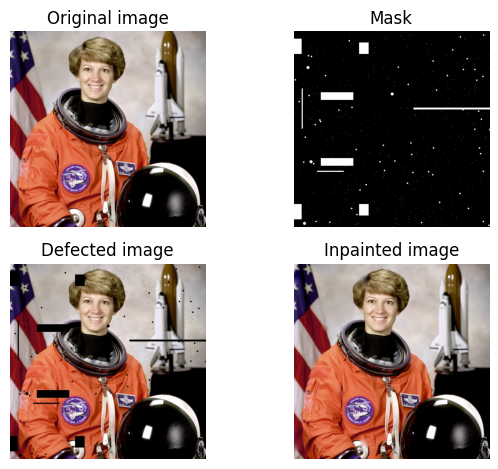

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data
from skimage.morphology import disk, dilation
from skimage.restoration import inpaint

image_orig = data.astronaut()

# Create mask with six block defect regions
mask = np.zeros(image_orig.shape[:-1], dtype=bool)
mask[20:60, 0:20] = 1
mask[160:180, 70:155] = 1
mask[30:60, 170:195] = 1
mask[-60:-30, 170:195] = 1
mask[-180:-160, 70:155] = 1
mask[-60:-20, 0:20] = 1

# Add a few long, narrow defects
mask[200:205, -200:] = 1
mask[150:255, 20:23] = 1
mask[365:368, 60:130] = 1

# Add randomly positioned small point-like defects
rstate = np.random.default_rng(0)
for radius in [0, 2, 4, 8]:
    # larger defects are less common
    thresh = 3 + 0.25 * radius  # make larger defects less common
    tmp_mask = rstate.standard_normal(image_orig.shape[:-1]) > thresh
    if radius > 0:
        tmp_mask = dilation(tmp_mask, disk(radius, dtype=bool))
    mask[tmp_mask] = 1

# Apply defect mask to the image over the same region in each color channel
image_defect = image_orig * ~mask[..., np.newaxis]

# image_result = inpaint.inpaint_biharmonic(image_defect, mask, channel_axis=-1)
image_result = inpaint.inpaint_biharmonic(image_orig, mask, channel_axis=-1)

fig, axes = plt.subplots(ncols=2, nrows=2)
ax = axes.ravel()

ax[0].set_title('Original image')
ax[0].imshow(image_orig)

ax[1].set_title('Mask')
ax[1].imshow(mask, cmap=plt.cm.gray)

ax[2].set_title('Defected image')
ax[2].imshow(image_defect)

ax[3].set_title('Inpainted image')
ax[3].imshow(image_result)

for a in ax:
    a.axis('off')

fig.tight_layout()
plt.show()

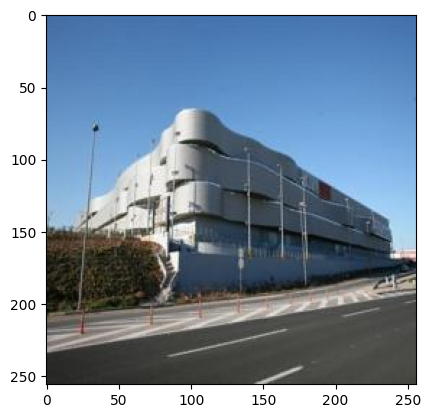

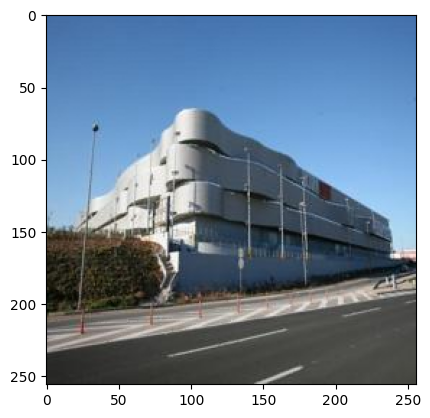

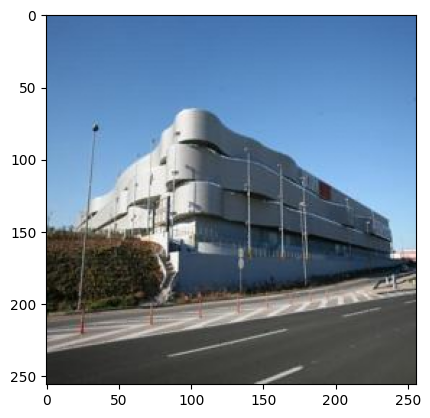

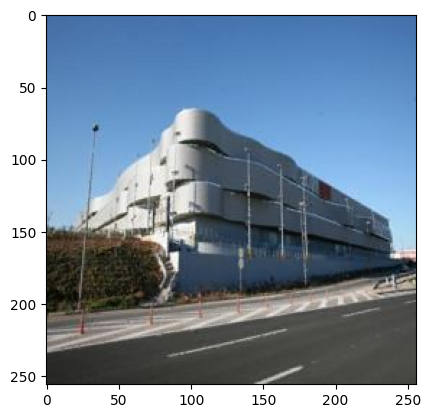

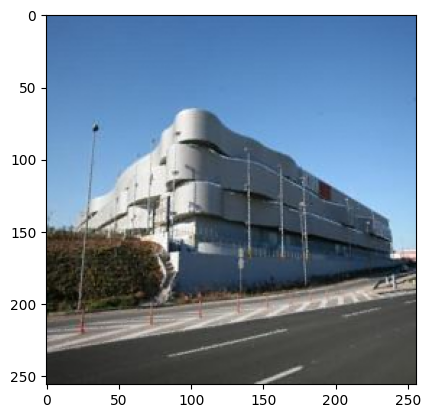

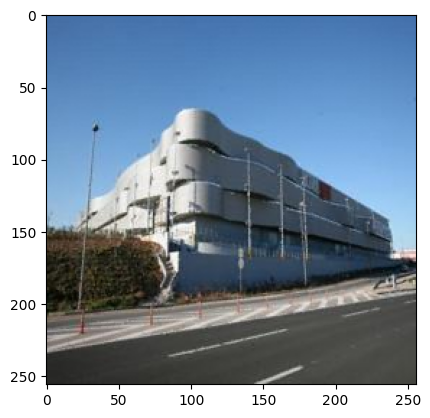

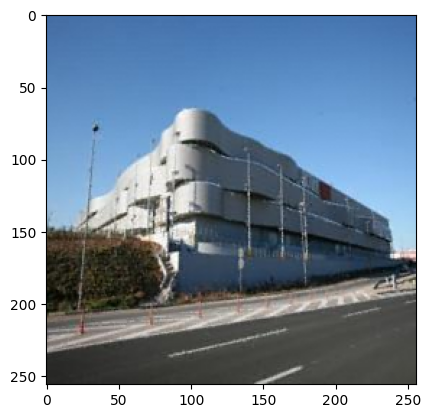

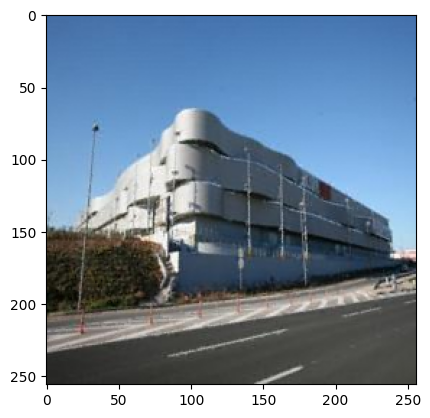

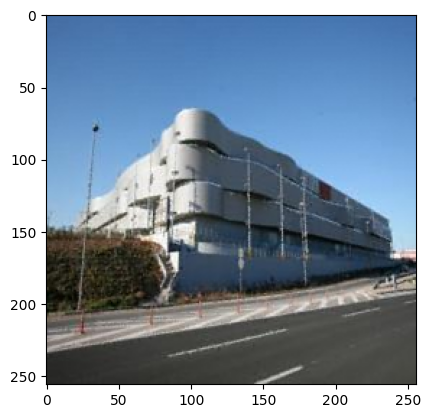

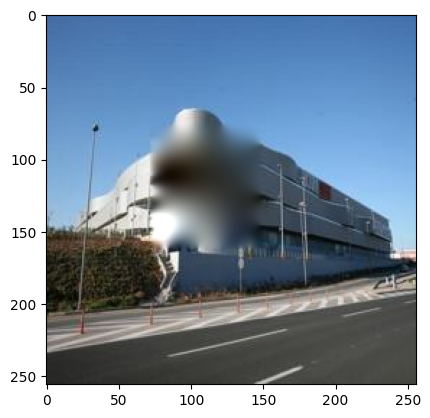

In [28]:
import matplotlib.pyplot as plt
output_list = sorted([f for f in os.listdir(output_dir)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))])
output_test = output_list[:10]
for out in output_test:
  out_path = os.path.join(output_dir, out)
  img = Image.open(out_path).convert('RGB')
  plt.imshow(img)
  plt.show()

